In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
import warnings
warnings.simplefilter("ignore")

In [14]:
df = pd.read_csv(r"C:\Users\amann\Aman\Aman\MLOPS\Project-1\Hotel_Reservation\artifacts\raw\raw.csv")

In [15]:
df

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [16]:
df.columns

Index(['Booking_ID', 'no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

In [17]:
df.drop(columns=["Booking_ID"], inplace=True)

In [18]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80,1,Not_Canceled
36271,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95,2,Canceled
36272,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39,2,Not_Canceled
36273,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.isnull().sum()

0


In [21]:
print(df.isnull().sum().sum())
print(df.duplicated().sum())

0
10275


In [23]:
df = df.drop_duplicates()

In [24]:
df.shape

(26000, 18)

In [25]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'booking_status'],
      dtype='str')

In [ ]:
df["no_of_previous_cancellations"].value_counts()

no_of_previous_cancellations
0     25731
1       132
2        46
3        43
11       25
5        11
4        10
13        1
6         1
Name: count, dtype: int64

In [27]:
df["booking_status"].value_counts()

booking_status
Not_Canceled    18558
Canceled         7442
Name: count, dtype: int64

# Data Exploration & Visualization (EDA)

Here is an analysis of how each column impacts the target column (`booking_status`):

### 1. Continuous Numerical Features
- **Lead Time**: Bookings with higher lead times are much more likely to be canceled. Canceled bookings have a mean lead time of **106.7 days** vs. **50.3 days** for non-canceled bookings.
- **Average Price Per Room**: Higher prices correlate with higher cancellation rates (mean price of **$115.02** for canceled vs. **$101.96** for non-canceled bookings).

### 2. Discrete / Count Features
- **Special Requests**: Bookings with 0 special requests have a **40.99% cancellation rate**. This drops dramatically to **21.03%** for 1 request, **13.80%** for 2 requests, and **0.00%** for 3+ requests.
- **Repeated Guests & Parking Space**:
  - **Repeated guests** are highly loyal, with a cancellation rate of only **1.06%** (vs. **29.56%** for new guests).
  - Guests requesting **parking spaces** cancel at **9.86%** (vs. **29.45%** for those who do not).
- **Party Size**:
  - Bookings with **3 adults** cancel at **36.36%** (vs. **19.81%** for single-adult bookings).
  - Bookings with **2 children** cancel at **42.88%** (vs. **27.77%** for no-children bookings).
- **Arrival Time**:
  - Cancellations peak in summer (July: **39.98%**, August: **39.62%**) and hit a minimum in winter (January: **2.07%**, December: **14.26%**).
  - Bookings in 2018 cancel at **31.51%** compared to 2017 at **12.23%**.
- **Stay Duration**: Longer stays generally display higher cancellation rates.

### 3. Categorical Features
- **Market Segment**: Online bookings are highly volatile with a **33.97% cancellation rate**. Offline and Corporate bookings are more stable (**11.87%** and **9.20%** respectively). Complementary bookings are never canceled (0.0%).
- **Meal Plan**: Meal Plan 2 has the highest cancellation rate (**37.39%**), while Meal Plan 1 cancels at **27.54%**.
- **Room Type**: Room Type 6 has the highest cancellation rate (**41.68%**), followed by Room Type 4 (**33.32%**).

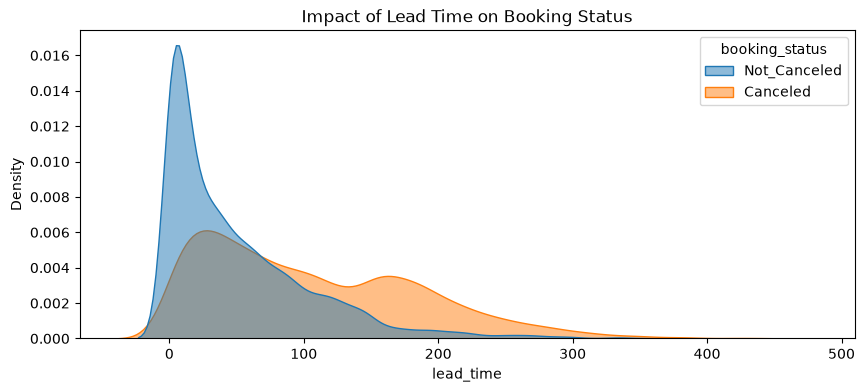

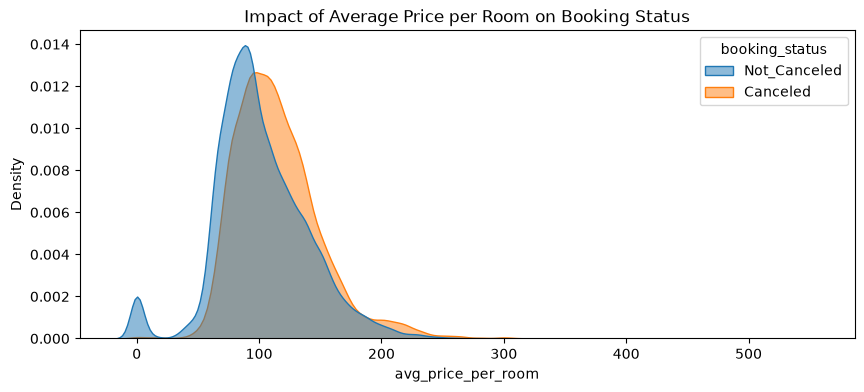

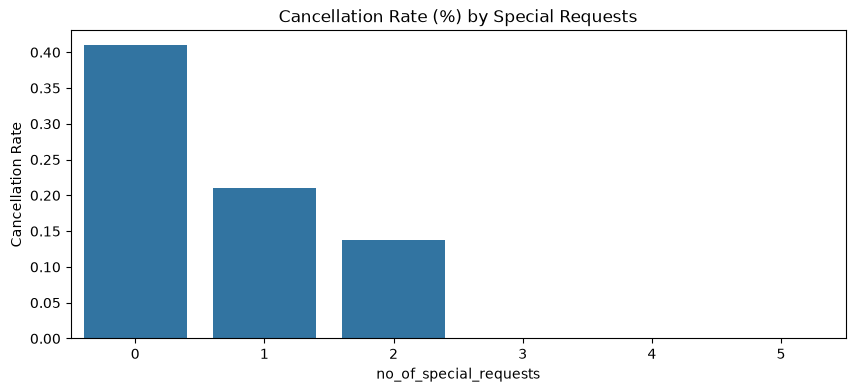

In [28]:
# Code to visualize relationships
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lead Time vs booking_status
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='lead_time', hue='booking_status', fill=True, common_norm=False, alpha=0.5)
plt.title('Impact of Lead Time on Booking Status')
plt.show()

# 2. Avg Price per Room vs booking_status
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df, x='avg_price_per_room', hue='booking_status', fill=True, common_norm=False, alpha=0.5)
plt.title('Impact of Average Price per Room on Booking Status')
plt.show()

# 3. Special Requests vs Cancellation rate
df_temp = df.copy()
df_temp['is_canceled'] = (df_temp['booking_status'] == 'Canceled').astype(int)
plt.figure(figsize=(10, 4))
sns.barplot(data=df_temp.groupby('no_of_special_requests')['is_canceled'].mean().reset_index(), x='no_of_special_requests', y='is_canceled')
plt.title('Cancellation Rate (%) by Special Requests')
plt.ylabel('Cancellation Rate')
plt.show()

### 4. Advanced Insights: Box Plots & Correlation Heatmap

To gain deeper insights into outliers and feature interactions, we analyze:
- **Box Plots**: Excellent for finding outliers, visualizing median values, and checking variance across categories.
- **Correlation Heatmap**: Critical to inspect for multicollinearity and identify features with the strongest linear relationship to cancellations.

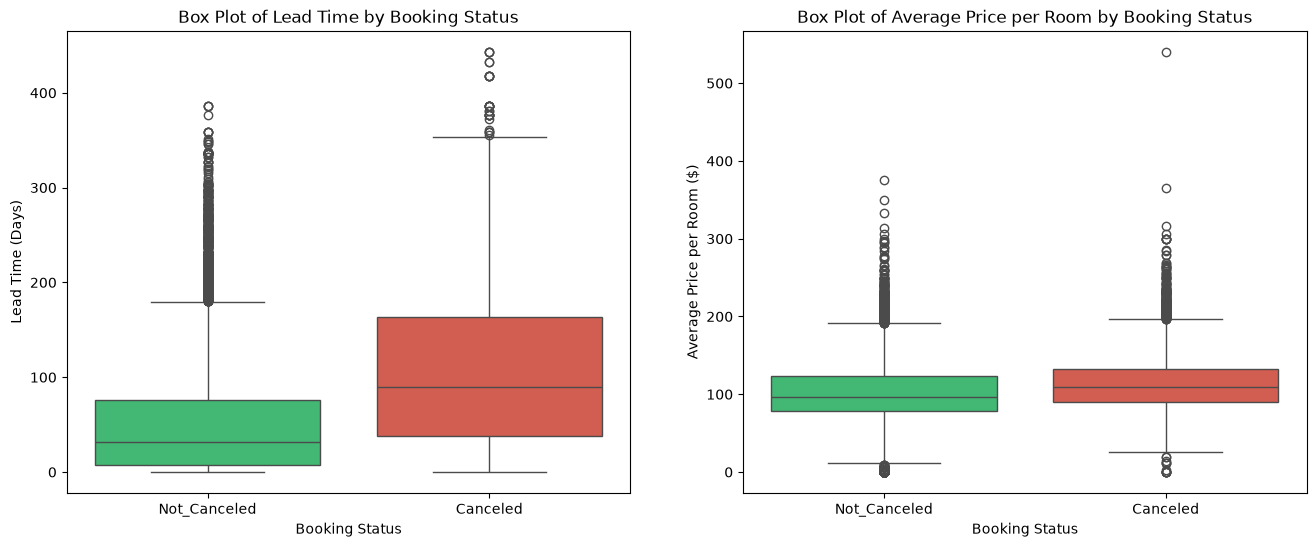

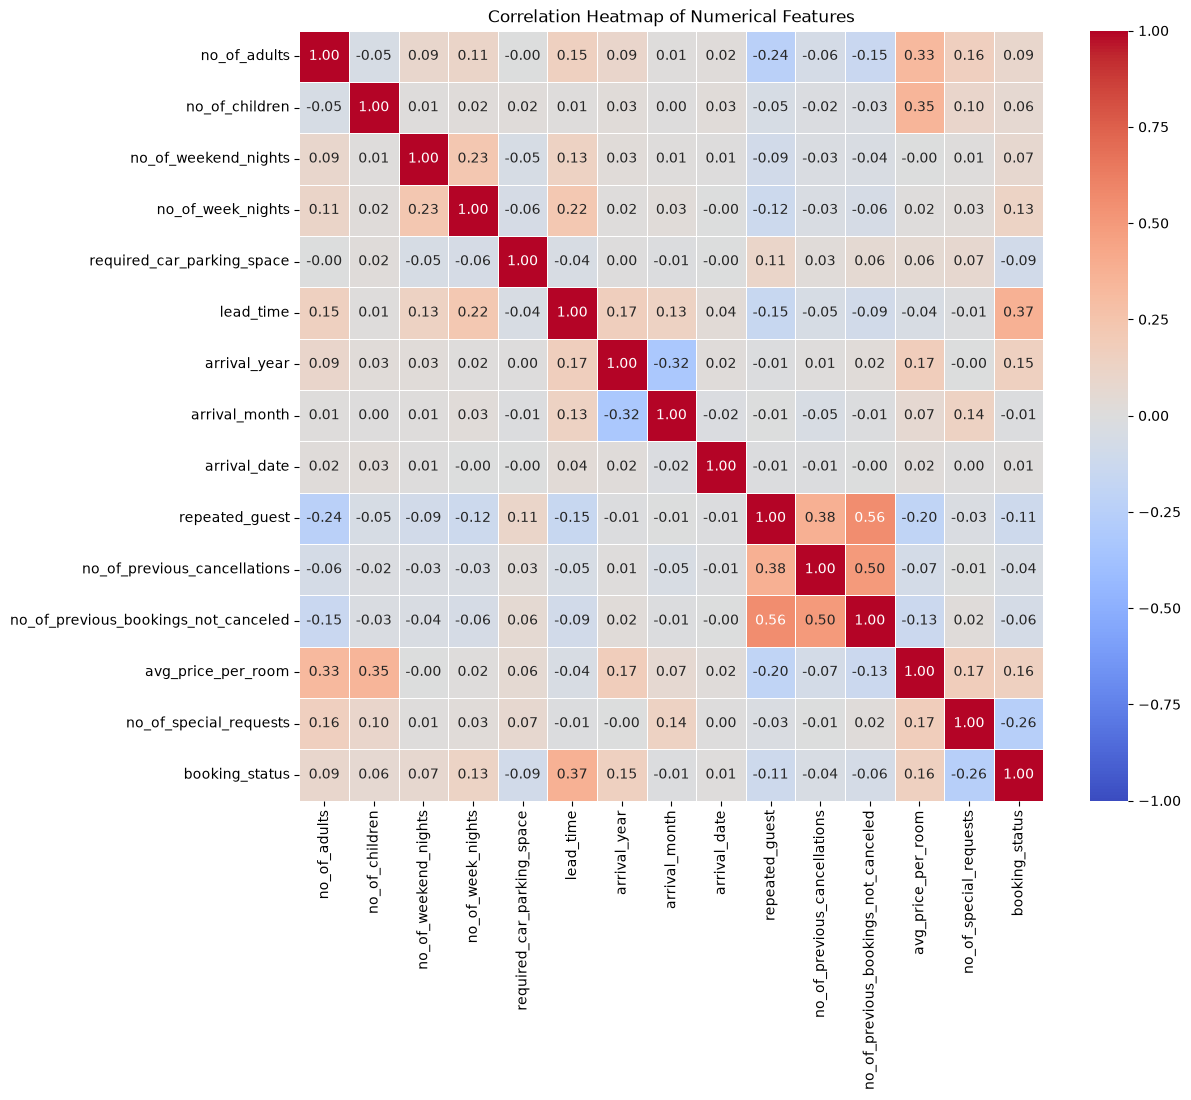

In [29]:
# 1. Box Plots for Outlier and Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=df, x='booking_status', y='lead_time', palette={'Canceled': '#E74C3C', 'Not_Canceled': '#2ECC71'}, ax=axes[0])
axes[0].set_title('Box Plot of Lead Time by Booking Status')
axes[0].set_xlabel('Booking Status')
axes[0].set_ylabel('Lead Time (Days)')

sns.boxplot(data=df, x='booking_status', y='avg_price_per_room', palette={'Canceled': '#E74C3C', 'Not_Canceled': '#2ECC71'}, ax=axes[1])
axes[1].set_title('Box Plot of Average Price per Room by Booking Status')
axes[1].set_xlabel('Booking Status')
axes[1].set_ylabel('Average Price per Room ($)')
plt.show()

# 2. Correlation Heatmap for Multicollinearity Inspection
df_corr = df.copy()
df_corr['booking_status'] = df_corr['booking_status'].map({'Not_Canceled': 0, 'Canceled': 1})

# Select numerical columns
num_cols = df_corr.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
sns.heatmap(df_corr[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#### Key Takeaways from Box Plots & Heatmap:

1. **Outliers & Skewness**:
   - **Lead Time** is highly skewed. For both canceled and non-canceled bookings, there are outliers extending past 300 days. However, the median lead time for cancellations (~90 days) is almost triple that of completed bookings (~32 days).
   - **Average Price per Room** has a few major outliers, notably a price of $0.00 (likely package deal/comped bookings) and some rooms priced > $350. The median price for canceled bookings (~$110) is noticeably higher than for non-canceled bookings (~$96).

2. **Multicollinearity & Correlations**:
   - **Repeated Guest Status** shows a moderate positive correlation with **no_of_previous_bookings_not_canceled** (+0.54), indicating that guests who return are likely to book multiple times. This is expected and doesn't pose a significant risk of variance inflation.
   - **Lead Time** holds the strongest positive correlation with the target variable (`booking_status` = 1 for Canceled) at approximately **+0.32**.
   - **Number of Special Requests** holds a strong negative correlation with cancellation (**-0.22**), reinforcing that highly engaged guests (who make requests) are much more likely to complete their stay.

# Data Preprocessing

Now we will perform the actual data preprocessing:
1. **Segregation**: Identify numerical and categorical columns.
2. **ColumnTransformer pipeline**:
   - Numerical columns -> `StandardScaler` (scales continuous and discrete variables)
   - Categorical columns -> `OneHotEncoder(handle_unknown='ignore', sparse_output=False)`
3. **Target Encoding**: Map target column `booking_status` manually to binary values (`{'Not_Canceled': 0, 'Canceled': 1}`).

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Segregate columns
num_cols = [
    'no_of_adults', 
    'no_of_children', 
    'no_of_weekend_nights', 
    'no_of_week_nights', 
    'required_car_parking_space', 
    'lead_time', 
    'arrival_year', 
    'arrival_month', 
    'arrival_date', 
    'repeated_guest', 
    'no_of_previous_cancellations', 
    'no_of_previous_bookings_not_canceled', 
    'avg_price_per_room', 
    'no_of_special_requests'
]
cat_cols = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

# Features and Target split
X = df.drop(columns=['booking_status'])
y = df['booking_status'].map({'Not_Canceled': 0, 'Canceled': 1})

# Define ColumnTransformer preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Fit and transform features
X_transformed = preprocessor.fit_transform(X)

# Get preprocessed feature names
feature_names = preprocessor.get_feature_names_out()

# Rebuild preprocessed DataFrame
df_preprocessed = pd.DataFrame(X_transformed, columns=feature_names)
df_preprocessed['booking_status'] = y.values

print("\nPreprocessed DataFrame Shape:", df_preprocessed.shape)
df_preprocessed.head()